In [5]:
import numpy as np
import pandas as pd
from sklearn.decomposition import NMF
import jax
from jax import numpy as jnp


In [29]:
newtonSteps = 50
def pos(m):
    m[m<0] = 0
    return m

def bilinear_proj(a, b, z, /):
    """Project onto bilinear function graph using Newton's method."""
    p = a @ b
    q = a @ a + b @ b
    def f(t):
        return ((1 + t**2) * p + t * q) / (1 - t**2) ** 2 - z + t

    
    f_prime = jax.grad(f)

    def newton_step(t):
        return t - f(t) / f_prime(t)

    t = jax.lax.fori_loop(0, newtonSteps, lambda _, t: newton_step(t), 0.0, unroll=True)

    a_new = (a + t * b) / (1 - t**2)
    b_new = (b + t * a) / (1 - t**2)

    return a_new, b_new


[np.float64(1711.3844204374388), np.float64(867.3572327625387)]
[np.float64(867.3572327625387), np.float64(867.3572327625387), np.float64(57.29919771417026)]
[np.float64(57.29919771417026), np.float64(57.29919771417026), np.float64(57.29919768959516)]
[np.float64(57.29919768959516), np.float64(57.29919768959516), np.float64(57.299197688160575)]
[np.float64(57.299197688160575), np.float64(57.299197688160575), np.float64(57.299197687916454)]
[np.float64(57.299197687916454), np.float64(57.299197687916454), np.float64(57.29919768783014)]
[np.float64(57.29919768783014), np.float64(57.29919768783014), np.float64(57.29919768781266)]
[np.float64(57.29919768781266), np.float64(57.29919768781266), np.float64(57.29919768780411)]
[np.float64(57.29919768780411), np.float64(57.29919768780411), np.float64(57.299197687792365)]
[np.float64(57.299197687792365), np.float64(57.299197687792365), np.float64(57.299197687792294)]
57.299197687792294 19
0.0009095151157769918
[[64.99237577 64.99237577 64.9923757

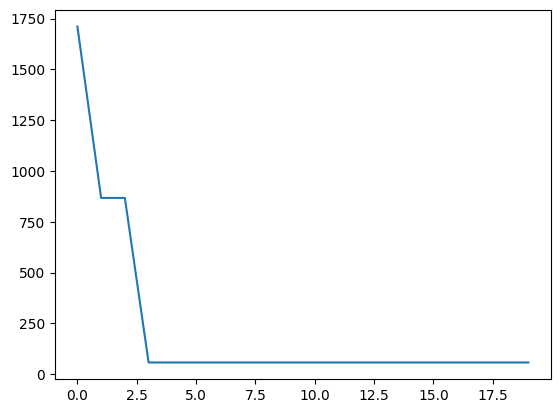

In [ ]:
### nmf using alternating projections   
samples=3

dimension=3
rankW = 3
Y = np.random.rand(dimension, samples)*100
W_A = np.random.rand(dimension, rankW )
X_A = np.linalg.pinv(W_A ) @Y
X_A = np.maximum(X_A, 0)


### perform nmf
norm = []
for iter in range(10):
    norm.append(np.linalg.norm( W_A @ X_A - Y))
    W_i = np.zeros((samples,dimension, rankW))
    X_i = np.zeros((samples, rankW, samples))
    for k in range(samples):
        x = np.zeros_like(X_A)
        w = np.zeros_like(W_A)

        ## projection of w on non-negative orthant
        w = pos(W_A)
        ## projection of x on non-negative orthant
        x[:,k] =  np.maximum(X_A[:,k],0)      
        tempx = np.zeros((rankW, rankW))
        for i in range(rankW):
            w[i,:],tempx[:,i] = bilinear_proj(w[i,:],x[:,k], Y[i,k])
        x = np.mean(tempx)
        W_i[k,:,:] = w
        X_i[k,:,:] = x
    W_A = np.mean(W_i, axis=0)
    X_A = np.mean(X_i, axis=0)
                
    norm.append(np.linalg.norm( W_A @ X_A - Y))
    
    print(norm[-3:])

import matplotlib.pyplot as plt
plt.plot(norm)
model = NMF(n_components=3, init='random', random_state=0)
W = model.fit_transform(Y)
H = model.components_
print(min(norm), np.argmin(norm))
print(np.linalg.norm(W @ H - Y))
print(W_A )
print(X_A)
        



In [25]:

### generate initial values for w and x
w = np.zeros((K, 3,3))
x = np.zeros((K, 3,3))

for k in range(K):
    ## for each data vector
    for i in range(3):
        for j in range(3):
            w[k, i, j] = W_A[i,j]
            x[k, i, j] = X_A[k,i]
            
def pos(m):
    m[m<0] = 0
    return m

def func(c, pdot, qdot, t):
    den = 1.0 - t * t
    return (pdot * (1.0 + t * t) + qdot * t) / (den * den) - c


def dfunc(pdot, qdot, t):
    den = 1.0 - t * t
    return (2.0 * pdot * t + qdot) / (den * den) + 4.0 * t * (pdot * (1.0 + t * t) + qdot * t) / (den * den * den)


def bilinproj(c, wold, zold):
    pdot = np.dot(wold, zold)
    qdot = np.dot(wold, wold) + np.dot(zold, zold)

    ta = 0.0
    f = func(c, pdot, qdot, ta)
    tb = -1.0 if f > 0 else 1.0

    for _ in range(50):
        df = dfunc(pdot, qdot, ta)
        t = ta - f / df

        if tb > ta:
            if t > tb:
                t = 0.5 * (ta + tb)
            f = func(c, pdot, qdot, t)
            if f > 0:
                tb = ta
        else:
            if t < tb:
                t = 0.5 * (ta + tb)
            f = func(c, pdot, qdot, t)
            if f < 0:
                tb = ta

        if abs(t - ta) < 1e-12:
            break
        ta = t

    den = 1.0 - t * t
    wnew = (wold + t * zold) / den
    znew = (zold + t * wold) / den
    return wnew, znew
norm = []
### perform RRR
for iter in range(1000):
    for k in range(K):
        ## projection of w on non-negative orthant
        w[k] = pos(w[k])
        ## projection of x on non-negative orthant
        x[k] = pos(x[k])
        ## projection of 
        ## -- alternate projection
        for i in range(3):
            w[k,i,:], x[k,i,:] = bilinproj( Y[k,i], w[k,i], x[k,i])
    ## average over all data points
    W_A = np.mean(w, axis=0)
    X_A = np.mean(x, axis=0)

    for k in range(K):
        ## for each data vector
        for i in range(3):
            for j in range(3):
                w[k, i, j] = W_A[i,j]
                x[k, i, j] = X_A[k,i]
                    #print(f"iter {iter} W_A {W_A} X_A {X_A}")
    norm.append(np.linalg.norm( W_A @ X_A - Y))


import matplotlib.pyplot as plt
plt.plot(norm)
model = NMF(n_components=3, init='random', random_state=0)
W = model.fit_transform(Y)
H = model.components_
print(min(norm), np.argmin(norm))
print(np.linalg.norm(W @ H - Y))
        
        

NameError: name 'K' is not defined